## Similarity Search by Hand

- **Compute vector similarities and distances**, including:
  - **L2 (Euclidean) distance**
  - **Dot product similarity and distance**
  - **Cosine similarity and distance**

- **Implement similarity calculations manually** using custom Python functions to reinforce core concepts.

- **Use built-in functions and methods** from external Python libraries (such as NumPy and PyTorch) to perform these computations efficiently.

- **Apply similarity measures to perform a basic similarity search**, comparing pairs of vectors to identify the most similar ones.

##### Recap Distance Algorithms

Below is the list of distance algorithms,

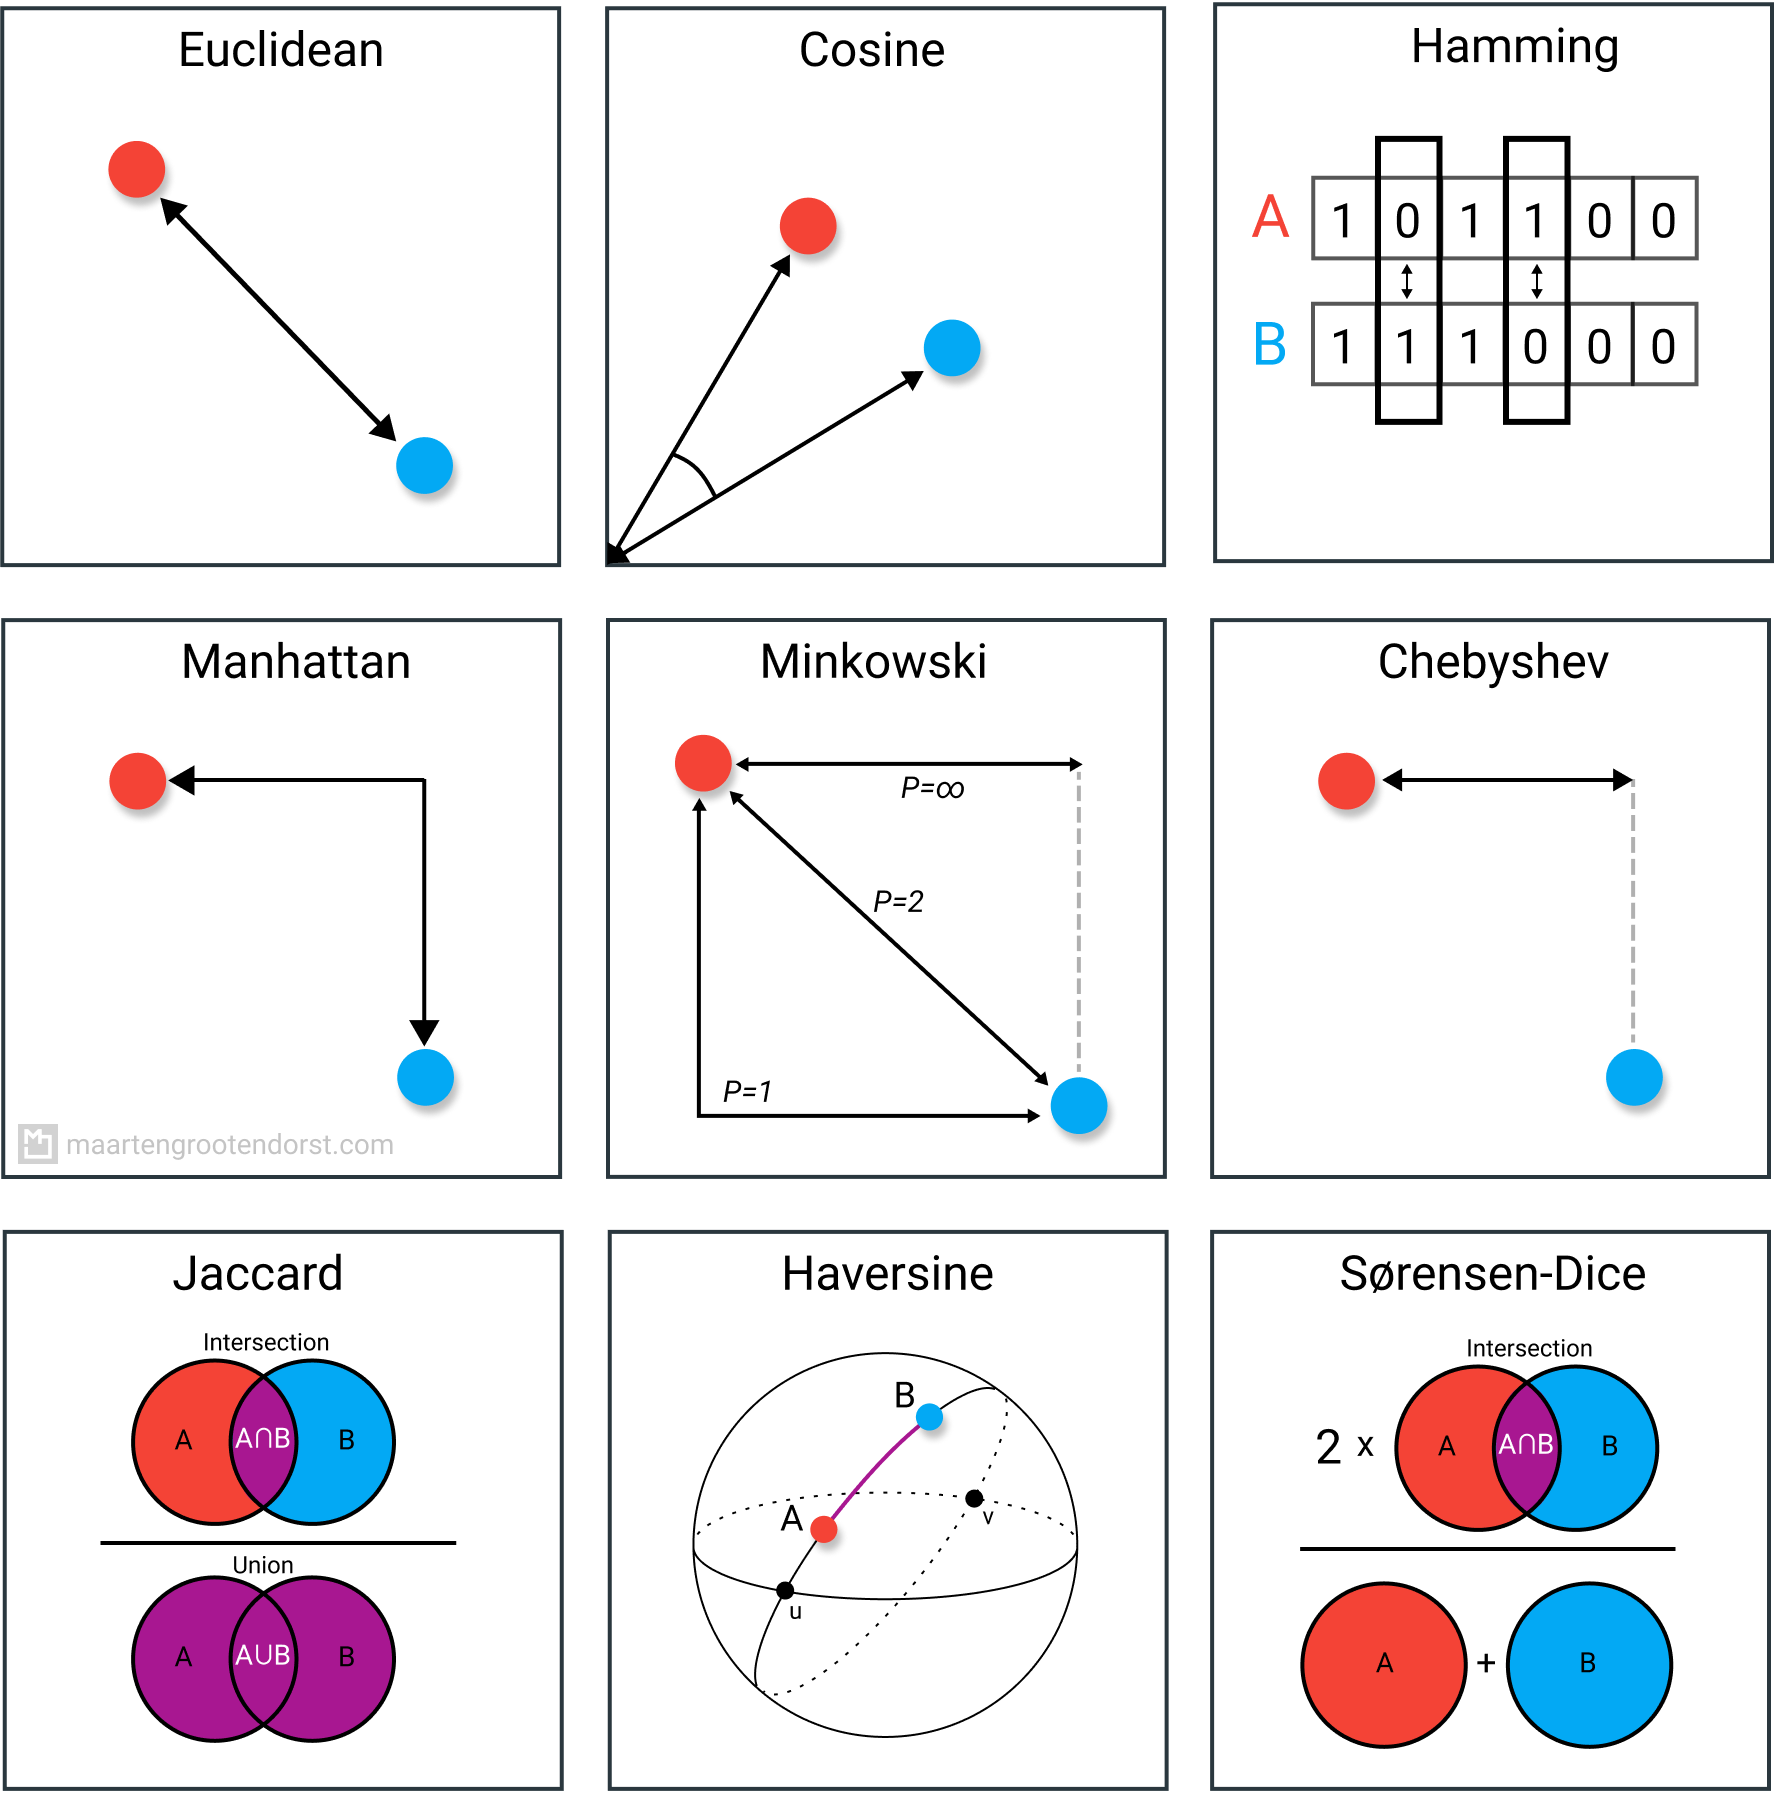

Below are the commonly used Similarity Metrics

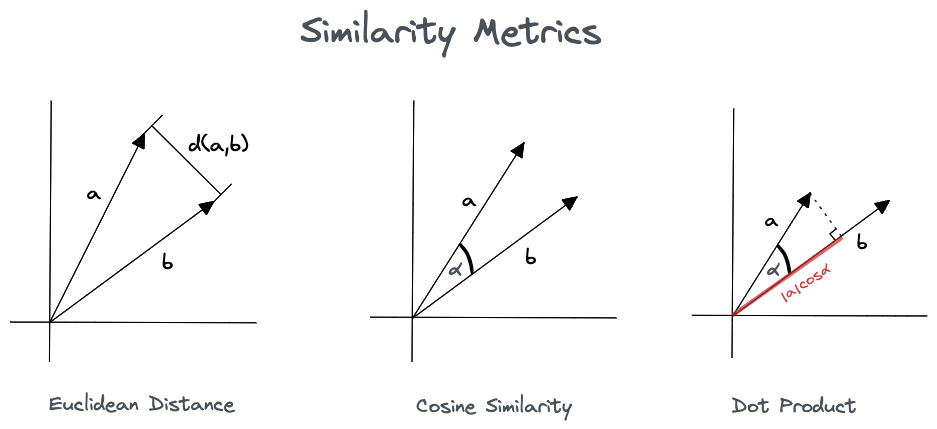

In [4]:
!pip3 install sentence-transformers==4.1.0 --break-system-packages | tail -n 1

In [5]:
import math
import numpy as np
import scipy
import torch
from sentence_transformers import SentenceTransformer

### Obtain Vector Embeddings

To calculate distance and similarity metrics, generate vector embeddings for some text documents.


There are four one-sentence documents, all starting with “Bugs,” but with different meanings by context. 

1. The first two are about software bugs
2. The last two are about insects/spiders. 

Meaning depends on surrounding terms (for example, “arachnologists” vs “lead developers”). 

In [6]:
# Example documents
documents = [
    'Bugs introduced by the intern had to be squashed by the lead developer.',
    'Bugs found by the quality assurance engineer were difficult to debug.',
    'Bugs are common throughout the warm summer months, according to the entomologist.',
    'Bugs, in particular spiders, are extensively studied by arachnologists.'
]

Define an embedding model to convert these texts into vectors.

Although this model trained for paraphrase matching, it works well for general semantic similarity.

In [7]:
# Load a pre-trained model
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

In [8]:
# Generate embeddings
embeddings = model.encode(documents)
print(embeddings.shape)
embeddings

(4, 384)


array([[-0.22804314, -0.24647701, -0.00319231, ...,  0.45528114,
         0.6341975 ,  0.537505  ],
       [-0.35791573, -0.32084015,  0.1596324 , ..., -0.07050698,
         0.9275026 ,  0.3437723 ],
       [ 0.20302981, -0.26898596,  0.16285151, ..., -0.1965097 ,
        -0.0337982 ,  0.5956153 ],
       [-0.04264314, -0.4572162 , -0.09526505, ..., -0.5803072 ,
         0.17248413,  0.09127847]], shape=(4, 384), dtype=float32)

### L2 (Euclidean) Distance

The L2 (Euclidean) distance between 2 vectors $a$ and $b$ can be calculated using

$\text{L2}(a,b) = \ \sqrt{\sum_{i=1}^n (a_i - b_i)^2} $


In [9]:
def euclidean_distance_fn(vector1, vector2):
    squared_sum = sum((x - y) ** 2 for x, y in zip(vector1, vector2))
    return math.sqrt(squared_sum)

In [10]:
euclidean_distance_fn(embeddings[0], embeddings[1])

5.96179017134276

In [11]:
euclidean_distance_fn(embeddings[1], embeddings[0])

5.96179017134276

In [12]:
l2_dist_manual = np.zeros([4,4])
for i in range(embeddings.shape[0]):
    for j in range(embeddings.shape[0]):
        l2_dist_manual[i,j] = euclidean_distance_fn(embeddings[i], embeddings[j])

l2_dist_manual

array([[0.        , 5.96179017, 7.33939807, 7.15578303],
       [5.96179017, 0.        , 7.7686165 , 7.39359177],
       [7.33939807, 7.7686165 , 0.        , 5.919928  ],
       [7.15578303, 7.39359177, 5.919928  , 0.        ]])

### 📝 Exercise 1 - Make the manual calculation more efficient

The code used to populate the `l2_dist_manual array` is not very efficient. First, it redundantly calculates the distance between a vector and itself, even though the L2 distance in such cases is always zero. Second, the array is symmetric—meaning the distance between vectors at indices $i$ and $j$ is the same as between $j$ and $i$. Therefore, each distance only needs to be computed once.

In the cell below, write an improved version of the code that avoids these inefficiencies. You only need to modify the part that says `### YOUR CODE GOES HERE ###`


In [13]:
l2_dist_manual_improved = np.zeros([4,4])
for i in range(embeddings.shape[0]):
    for j in range(embeddings.shape[0]):
        ### YOUR CODE GOES HERE ###
        if i == j or l2_dist_manual_improved[i, j] != 0:
            continue
        distance = euclidean_distance_fn(embeddings[i], embeddings[j])
        l2_dist_manual_improved[i, j] = distance
        l2_dist_manual_improved[j, i] = distance

l2_dist_manual_improved

array([[0.        , 5.96179017, 7.33939807, 7.15578303],
       [5.96179017, 0.        , 7.7686165 , 7.39359177],
       [7.33939807, 7.7686165 , 0.        , 5.919928  ],
       [7.15578303, 7.39359177, 5.919928  , 0.        ]])

### Calculate L2 Distance using `scipy`

In [14]:
l2_dist_scipy = scipy.spatial.distance.cdist(embeddings, embeddings, 'euclidean')
l2_dist_scipy

array([[0.        , 5.96179052, 7.33939956, 7.15578196],
       [5.96179052, 0.        , 7.76861683, 7.39359124],
       [7.33939956, 7.76861683, 0.        , 5.91992743],
       [7.15578196, 7.39359124, 5.91992743, 0.        ]])

In [15]:
np.allclose(l2_dist_manual, l2_dist_scipy)

True

### Dot Product Similarity and Distance

The dot product between vectors $a$ and $b$ is calculated using

$ a \cdot b = \sum_{i=1}^{n} a_i b_i $

In [17]:
def dot_product_fn(vector1, vector2):
    return sum(x * y for x, y in zip(vector1, vector2))

In [18]:
dot_product_fn(embeddings[0], embeddings[1])

np.float32(18.53539)

The dot-product matrix has non-zero diagonal values (self-similarity), which can be ignored. Off-diagonal values are symmetric. Since dot product measures similarity, higher means closer meaning. Here it worked well: sentences 1–2 are most similar, and 3–4 are most similar.

In [19]:
dot_product_manual = np.empty([4,4])
for i in range(embeddings.shape[0]):
    for j in range(embeddings.shape[0]):
        dot_product_manual[i,j] = dot_product_fn(embeddings[i], embeddings[j])

dot_product_manual

array([[33.74440384, 18.53539085,  8.56981087,  7.83092499],
       [18.53539085, 38.86931992,  7.88995934,  8.66340446],
       [ 8.56981087,  7.88995934, 37.26200867, 17.66955948],
       [ 7.83092499,  8.66340446, 17.66955948, 33.12266541]])

##### Calculate the dot product using matrix multiplication


In [20]:
# Matrix multiplication operator
dot_product_operator = embeddings @ embeddings.T
dot_product_operator

array([[33.74442  , 18.5354   ,  8.569811 ,  7.8309317],
       [18.5354   , 38.86933  ,  7.8899603,  8.663401 ],
       [ 8.569811 ,  7.8899603, 37.262    , 17.669558 ],
       [ 7.8309317,  8.663401 , 17.669558 , 33.12266  ]], dtype=float32)

In [22]:
np.matmul(embeddings,embeddings.T) # For 2-D matrices can be used as well

array([[33.74442  , 18.5354   ,  8.569811 ,  7.8309317],
       [18.5354   , 38.86933  ,  7.8899603,  8.663401 ],
       [ 8.569811 ,  7.8899603, 37.262    , 17.669558 ],
       [ 7.8309317,  8.663401 , 17.669558 , 33.12266  ]], dtype=float32)

In [23]:
np.dot(embeddings,embeddings.T)

array([[33.74442  , 18.5354   ,  8.569811 ,  7.8309317],
       [18.5354   , 38.86933  ,  7.8899603,  8.663401 ],
       [ 8.569811 ,  7.8899603, 37.262    , 17.669558 ],
       [ 7.8309317,  8.663401 , 17.669558 , 33.12266  ]], dtype=float32)

In [21]:
np.allclose(dot_product_manual, dot_product_operator, atol=1e-05)

True

##### Calculate dot product distance

Because dot product is a similarity score (bigger = more similar), multiplying by -1 flips it into a distance-like score (smaller/more negative = more similar, larger/less negative = less similar). It preserves ranking but is not a true metric distance.

In [24]:
dot_product_distance = -dot_product_manual
dot_product_distance

array([[-33.74440384, -18.53539085,  -8.56981087,  -7.83092499],
       [-18.53539085, -38.86931992,  -7.88995934,  -8.66340446],
       [ -8.56981087,  -7.88995934, -37.26200867, -17.66955948],
       [ -7.83092499,  -8.66340446, -17.66955948, -33.12266541]])

### Cosine Similarity and Distance

The cosine similarity between vectors $a$ and $b$ is calculated using

$ \text{cossim}(a, b) = \frac{a \cdot b}{||a|| \ ||b||} =  \frac{a}{||a||} \cdot \frac{b}{||b||} $

where $||a|| = \sqrt{\sum_{k=1}^n a_k^2}$ is the L2 norm, or the magnitude, of vector $a$, and $\cdot$ is the dot product.

Also note that $\frac{a}{||a||}$ represents a normalized vector. This means it has the same direction as vector $a$ but a magnitude (or length) of 1. Thus, cosine similarity can be calculated by taking the dot product of two normalized vectors.


##### Calculate the L2 norm

In [25]:
# L2 norms
l2_norms = np.sqrt(np.sum(embeddings**2, axis=1))
l2_norms

array([5.8089943, 6.2345276, 6.1042604, 5.755229 ], dtype=float32)

In [26]:
# L2 norms reshaped
l2_norms_reshaped = l2_norms.reshape(-1,1)
l2_norms_reshaped

array([[5.8089943],
       [6.2345276],
       [6.1042604],
       [5.755229 ]], dtype=float32)

##### Normalize embedding vectors

In [27]:
normalized_embeddings_manual = embeddings/l2_norms_reshaped
normalized_embeddings_manual

array([[-0.0392569 , -0.04243024, -0.00054955, ...,  0.07837521,
         0.10917509,  0.09252978],
       [-0.05740864, -0.05146182,  0.02560457, ..., -0.01130911,
         0.14876871,  0.05514007],
       [ 0.03326035, -0.04406528,  0.02667834, ..., -0.03219222,
        -0.00553682,  0.09757371],
       [-0.00740946, -0.07944362, -0.01655278, ..., -0.10083129,
         0.02996998,  0.01586009]], shape=(4, 384), dtype=float32)

In [29]:
normalized_embeddings_manual.shape

(4, 384)

### 📝 Exercise 2 - Verify that vectors are normalized

Verify that `normalized_embeddings_manual` are normalized vectors by making sure that the length of each vector is equal to 1.

In [36]:
### YOUR CODE GOES HERE ###
np.sqrt(np.sum(normalized_embeddings_manual**2, axis=1))

array([0.99999994, 0.99999994, 1.        , 1.        ], dtype=float32)

##### Normalize embeddings using PyTorch


In [37]:
normalized_embeddings_torch = torch.nn.functional.normalize(
    torch.from_numpy(embeddings)
).numpy()
normalized_embeddings_torch

array([[-0.0392569 , -0.04243024, -0.00054955, ...,  0.07837521,
         0.10917509,  0.09252978],
       [-0.05740863, -0.05146182,  0.02560457, ..., -0.01130911,
         0.1487687 ,  0.05514007],
       [ 0.03326035, -0.04406528,  0.02667834, ..., -0.03219222,
        -0.00553682,  0.09757371],
       [-0.00740946, -0.07944363, -0.01655278, ..., -0.1008313 ,
         0.02996999,  0.0158601 ]], shape=(4, 384), dtype=float32)

In [38]:
np.allclose(normalized_embeddings_manual, normalized_embeddings_torch)

True

##### Calculate cosine similarity manually

In [39]:
dot_product_fn(normalized_embeddings_manual[0], normalized_embeddings_manual[1])

np.float32(0.51179665)

In [40]:
cosine_similarity_manual = np.empty([4,4])
for i in range(normalized_embeddings_manual.shape[0]):
    for j in range(normalized_embeddings_manual.shape[0]):
        cosine_similarity_manual[i,j] = dot_product_fn(
            normalized_embeddings_manual[i], 
            normalized_embeddings_manual[j]
        )

cosine_similarity_manual

array([[1.        , 0.51179665, 0.24167804, 0.2342339 ],
       [0.51179665, 1.00000024, 0.20731851, 0.24144726],
       [0.24167804, 0.20731851, 1.00000072, 0.50295585],
       [0.2342339 , 0.24144726, 0.50295585, 1.        ]])

##### Calculate cosine similarity using matrix multiplication

In [41]:
cosine_similarity_operator = normalized_embeddings_manual @ normalized_embeddings_manual.T
cosine_similarity_operator

array([[0.9999999 , 0.5117967 , 0.24167809, 0.23423389],
       [0.5117967 , 1.        , 0.20731857, 0.24144727],
       [0.24167809, 0.20731857, 1.0000001 , 0.5029561 ],
       [0.23423389, 0.24144727, 0.5029561 , 1.        ]], dtype=float32)

In [42]:
np.allclose(cosine_similarity_manual, cosine_similarity_operator)

True

##### Calculate cosine distance

The cosine distance between vectors $a$ and $b$ is simply 1 minus the cosine similarity between $a$ and $b$:

$1 - cossim(a,b)$

In [43]:
1 - cosine_similarity_manual


array([[ 0.00000000e+00,  4.88203347e-01,  7.58321956e-01,
         7.65766099e-01],
       [ 4.88203347e-01, -2.38418579e-07,  7.92681485e-01,
         7.58552745e-01],
       [ 7.58321956e-01,  7.92681485e-01, -7.15255737e-07,
         4.97044146e-01],
       [ 7.65766099e-01,  7.58552745e-01,  4.97044146e-01,
         0.00000000e+00]])

### 📝 Exercise 3 - Similarity Search Using a Query

In the above examples, we calculated similarity between 4 documents:

```python
documents = [
    'Bugs introduced by the intern had to be squashed by the lead developer.',
    'Bugs found by the quality assurance engineer were difficult to debug.',
    'Bugs are common throughout the warm summer months, according to the entomologist.',
    'Bugs, in particular spiders, are extensively studied by arachnologists.'
]
```

Now, your task is to find which of these 4 documents is most similar to the query `Who is responsible for a coding project and fixing others' mistakes?` using cosine similarity. You can reuse the `documents` and `normalized_embeddings_manual` arrays in your answer:


In [54]:
### YOUR CODE GOES HERE ###
new_documents = [
    'Bugs introduced by the intern had to be squashed by the lead developer.',
    'Bugs found by the quality assurance engineer were difficult to debug.',
    'Bugs are common throughout the warm summer months, according to the entomologist.',
    'Bugs, in particular spiders, are extensively studied by arachnologists.'
]
new_embeddings = model.encode(new_documents + ["Who is responsible for a coding project and fixing others' mistakes?"])
new_l2_norms = np.sqrt(np.sum(new_embeddings**2, axis=1))
new_l2_norms_reshaped = new_l2_norms.reshape(-1,1)
new_normalized_embeddings_manual = new_embeddings/new_l2_norms_reshaped

cosine_sim_result = new_normalized_embeddings_manual @ new_normalized_embeddings_manual.T
result_index = np.argmin(1 - cosine_sim_result[-1][:-1], axis=0)
new_documents[result_index]

'Bugs introduced by the intern had to be squashed by the lead developer.'